# Part 3 — FinBERT Sentiment Analysis

See `README.md` for project context and motivation.

This notebook applies **FinBERT** (Araci 2019; `ProsusAI/finbert`) to each
earnings call transcript to extract document-level sentiment scores
(positive / negative / neutral with probabilities). The results are then
merged with the LDA topic assignments and geoeconomic risk flags from
Parts 1 and 2 to answer:

- Which LDA topics are discussed with negative vs positive tone?
- Does sentiment shift across reporting quarters?
- Do executives speak more positively than analysts?
- Are geoeconomically-flagged transcripts more negatively toned?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

print('Setup complete.')

Setup complete.


## 2. Run inference (via `05a_finbert_inference.py`)

Inference is handled by the companion script **`05a_finbert_inference.py`**,
which batches efficiently and saves incremental checkpoints so a long run can
be safely interrupted and resumed.

```bash
# Full corpus (~1–2 h on CPU; ~5 min on GPU)
python 05a_finbert_inference.py

# Test on first 100 documents
python 05a_finbert_inference.py --limit 100

# Resume an interrupted run
python 05a_finbert_inference.py --resume
```

Once the script has finished, `data/finbert_sentiment.csv` is available and
the cells below will load it automatically.

In [2]:
CACHE_PATH = Path("data/finbert_sentiment.csv")

if not CACHE_PATH.exists():
    raise FileNotFoundError(
        f"{CACHE_PATH} not found.\n"
        "Run the inference script first:\n"
        "  python 05a_finbert_inference.py\n"
        "or for a quick test:\n"
        "  python 05a_finbert_inference.py --limit 100"
    )

sent_df = pd.read_csv(CACHE_PATH)
print(f"Loaded {CACHE_PATH}: {len(sent_df):,} rows, {len(sent_df.columns)} columns")
sent_df.head(3)

Loaded data/finbert_sentiment.csv: 100 rows, 16 columns


,url,full_text__p_positive,full_text__p_negative,full_text__p_neutral,full_text__sentiment,full_text__n_chunks,exec_text__p_positive,exec_text__p_negative,exec_text__p_neutral,exec_text__sentiment,exec_text__n_chunks,analyst_text__p_positive,analyst_text__p_negative,analyst_text__p_neutral,analyst_text__sentiment,analyst_text__n_chunks
0,https://www.investing.com/news/transcripts/-93...,0.354866,0.036314,0.608820,neutral,9,0.402260,0.035128,0.562612,neutral,6,0.249103,0.020230,0.730667,neutral,3
1,https://www.investing.com/news/transcripts/-93...,0.414514,0.025450,0.560036,neutral,8,0.414346,0.025378,0.560275,neutral,8,0.079613,0.037081,0.883306,neutral,1
2,https://www.investing.com/news/transcripts/-93...,0.273378,0.027196,0.699426,neutral,16,0.362058,0.020452,0.617490,neutral,6,0.234785,0.091035,0.674180,neutral,10


## 4. Merge with metadata, LDA topics, and geoeconomic flags

In [3]:
corpus = pd.read_csv('data/corpus_documents.csv',
                     usecols=['url', 'company_name', 'ticker',
                              'reporting_period', 'event_type'])

meta_cols = ['url', 'company_name', 'ticker', 'reporting_period', 'event_type']
meta = corpus[meta_cols].copy()

# LDA dominant topic
gamma = pd.read_csv('data/doc_topic_distributions.csv',
                    usecols=['url', 'dominant_topic', 'dominant_label'])

# Geoeconomic risk flags
geo = pd.read_csv('data/geoeconomic_matches.csv',
                  usecols=['url', 'trade_risk', 'sanctions_risk',
                           'embargo_risk', 'geopolitical_risk', 'any_georisk'])

df = (
    sent_df
    .merge(meta,  on='url', how='left')
    .merge(gamma, on='url', how='left')
    .merge(geo,   on='url', how='left')
)

df['net_sentiment'] = df['full_text__p_positive'] - df['full_text__p_negative']
df['exec_net']      = df['exec_text__p_positive'] - df['exec_text__p_negative']
df['analyst_net']   = df['analyst_text__p_positive'] - df['analyst_text__p_negative']

# Q1 2025 has no transcripts in this corpus; start from Q2 2025
PERIOD_ORDER = ['Q2 2025', 'Q3 2025', 'Q4 2025',
                'Q1 2026', 'Q2 2026', 'Q3 2026', 'Q4 2026']
df['reporting_period'] = pd.Categorical(
    df['reporting_period'], categories=PERIOD_ORDER, ordered=True
)

print(f"Merged: {len(df):,} rows")
print(df[['reporting_period', 'dominant_label', 'full_text__sentiment',
          'net_sentiment', 'any_georisk']].describe(include='all').T)

Merged: 100 rows
                      count unique                       top freq      mean  \
reporting_period          3      2                   Q4 2025    2       NaN   
dominant_label          100     12  Biotechnology & Drug R&D   21       NaN   
full_text__sentiment    100      2                   neutral   97       NaN   
net_sentiment         100.0    NaN                       NaN  NaN  0.177487   
any_georisk             100      2                     False   91       NaN   

                           std       min       25%       50%      75%  \
reporting_period           NaN       NaN       NaN       NaN      NaN   
dominant_label             NaN       NaN       NaN       NaN      NaN   
full_text__sentiment       NaN       NaN       NaN       NaN      NaN   
net_sentiment         0.116532 -0.004648  0.108807  0.145966  0.22786   
any_georisk                NaN       NaN       NaN       NaN      NaN   

                           max  
reporting_period           NaN  
dom

## 5. Visualisations

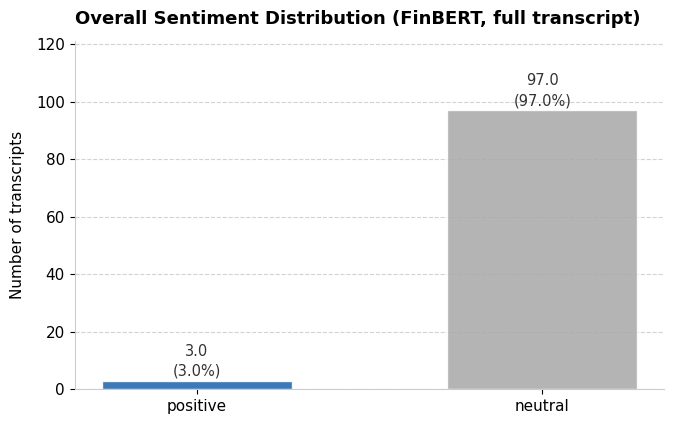

Saved figures/14_finbert_sentiment_dist.png


In [4]:
# ── Fig 1: Overall sentiment distribution ──────────────────────────────────

SENT_COLORS = {'positive': '#2166AC', 'neutral': '#AAAAAA', 'negative': '#D6604D'}

counts = df['full_text__sentiment'].value_counts().reindex(
    ['positive', 'neutral', 'negative'])
total  = counts.sum()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(counts.index, counts.values,
              color=[SENT_COLORS[s] for s in counts.index],
              alpha=0.88, edgecolor='white', linewidth=1.0, width=0.55)

for bar, (label, count) in zip(bars, counts.items()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.008,
            f'{count:,}\n({100*count/total:.1f}%)',
            ha='center', va='bottom', fontsize=10.5, color='#333333',
            linespacing=1.4)

ax.set_ylabel('Number of transcripts', fontsize=11, labelpad=8)
ax.set_title('Overall Sentiment Distribution (FinBERT, full transcript)',
             fontsize=13, fontweight='bold', pad=12, loc='left')
ax.set_ylim(0, counts.max() * 1.25)
ax.yaxis.grid(True, linestyle='--', alpha=0.35, color='grey', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
plt.tight_layout(pad=1.5)
plt.savefig('figures/14_finbert_sentiment_dist.png', dpi=160,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved figures/14_finbert_sentiment_dist.png')

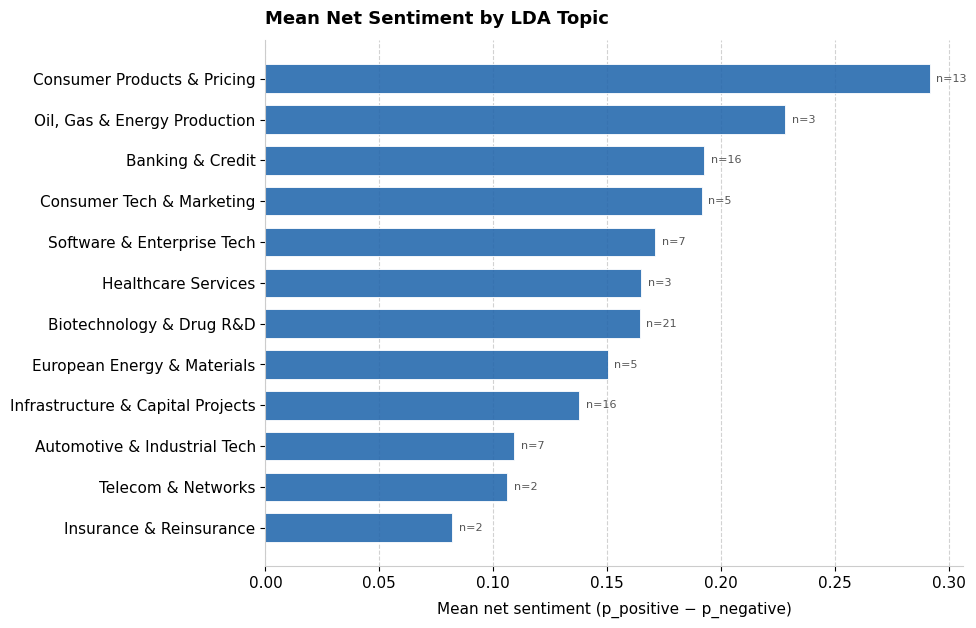

Saved figures/15_finbert_by_topic.png


In [5]:
# ── Fig 2: Net sentiment by LDA topic ──────────────────────────────────────
# Net sentiment = p_positive - p_negative; higher = more positive tone.

topic_sent = (
    df.dropna(subset=['dominant_label', 'net_sentiment'])
    .groupby('dominant_label')
    .agg(mean_net=('net_sentiment', 'mean'),
         n=('net_sentiment', 'count'))
    .sort_values('mean_net')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, max(5, len(topic_sent) * 0.42 + 1.5)))
colors = ['#D6604D' if v < 0 else '#2166AC' for v in topic_sent['mean_net']]
bars   = ax.barh(topic_sent['dominant_label'], topic_sent['mean_net'],
                 color=colors, alpha=0.88, edgecolor='white',
                 linewidth=0.7, height=0.7)

for bar, (_, row) in zip(bars, topic_sent.iterrows()):
    x_pos = row['mean_net'] + (0.003 if row['mean_net'] >= 0 else -0.003)
    ha    = 'left' if row['mean_net'] >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"n={row['n']:,}", va='center', ha=ha,
            fontsize=8, color='#555555')

ax.axvline(0, color='#888888', linewidth=1.2, linestyle='--')
ax.set_xlabel('Mean net sentiment (p_positive − p_negative)', fontsize=11,
              labelpad=8)
ax.set_title('Mean Net Sentiment by LDA Topic',
             fontsize=13, fontweight='bold', pad=12, loc='left')
ax.xaxis.grid(True, linestyle='--', alpha=0.35, color='grey', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
plt.tight_layout(pad=1.5)
plt.savefig('figures/15_finbert_by_topic.png', dpi=160,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved figures/15_finbert_by_topic.png')

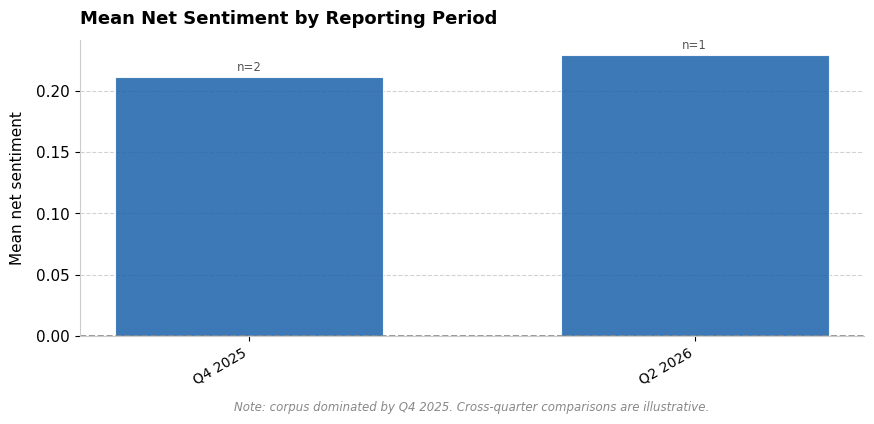

Saved figures/16_finbert_by_period.png


In [6]:
# ── Fig 3: Net sentiment by reporting period ────────────────────────────────

period_sent = (
    df.dropna(subset=['reporting_period', 'net_sentiment'])
    .groupby('reporting_period', observed=True)
    .agg(mean_net=('net_sentiment', 'mean'),
         n=('net_sentiment', 'count'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(period_sent))
colors = ['#D6604D' if v < 0 else '#2166AC' for v in period_sent['mean_net']]
bars   = ax.bar(x, period_sent['mean_net'], color=colors, alpha=0.88,
                edgecolor='white', linewidth=0.8, width=0.60)

for xi, (_, row) in enumerate(period_sent.iterrows()):
    y_off = 0.002 if row['mean_net'] >= 0 else -0.002
    va    = 'bottom' if row['mean_net'] >= 0 else 'top'
    ax.text(xi, row['mean_net'] + y_off,
            f"n={row['n']:,}", ha='center', va=va,
            fontsize=8.5, color='#555555')

ax.axhline(0, color='#888888', linewidth=1.2, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(period_sent['reporting_period'].astype(str),
                   rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Mean net sentiment', fontsize=11, labelpad=8)
ax.set_title('Mean Net Sentiment by Reporting Period',
             fontsize=13, fontweight='bold', pad=12, loc='left')
ax.set_xlabel(
    'Note: corpus dominated by Q4 2025. Cross-quarter comparisons are illustrative.',
    fontsize=8.5, color='#888888', labelpad=10, style='italic'
)
ax.yaxis.grid(True, linestyle='--', alpha=0.35, color='grey', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
plt.tight_layout(pad=1.5)
plt.savefig('figures/16_finbert_by_period.png', dpi=160,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved figures/16_finbert_by_period.png')

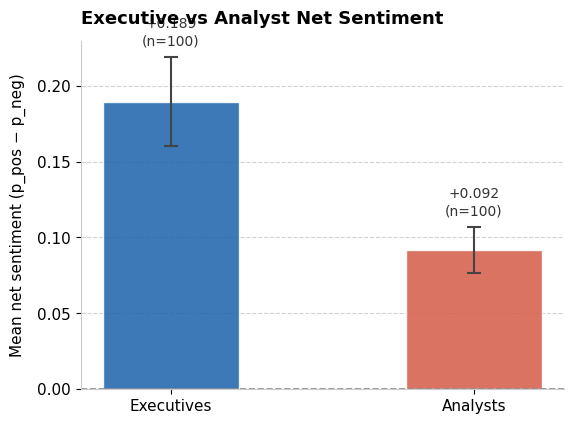

Saved figures/17_finbert_exec_vs_analyst.png


In [7]:
# ── Fig 4: Executive vs analyst net sentiment ───────────────────────────────

role_data = pd.DataFrame({
    'Role':         ['Executives', 'Analysts'],
    'mean_net':     [df['exec_net'].mean(), df['analyst_net'].mean()],
    'std':          [df['exec_net'].std(),  df['analyst_net'].std()],
    'n':            [df['exec_net'].notna().sum(), df['analyst_net'].notna().sum()],
})
role_data['se'] = role_data['std'] / np.sqrt(role_data['n'])

fig, ax = plt.subplots(figsize=(6, 4.5))
ROLE_COLORS = ['#2166AC', '#D6604D']
bars = ax.bar(role_data['Role'], role_data['mean_net'],
              color=ROLE_COLORS, alpha=0.88, edgecolor='white',
              linewidth=1.0, width=0.45,
              yerr=role_data['se'] * 1.96, capsize=5,
              error_kw={'elinewidth': 1.5, 'ecolor': '#444444', 'capthick': 1.5})

for bar, (_, row) in zip(bars, role_data.iterrows()):
    y_off = 0.002 if row['mean_net'] >= 0 else -0.002
    ax.text(bar.get_x() + bar.get_width() / 2,
            row['mean_net'] + row['se'] * 1.96 + abs(y_off) * 3,
            f"{row['mean_net']:+.3f}\n(n={row['n']:,})",
            ha='center', va='bottom', fontsize=10, color='#333333',
            linespacing=1.3)

ax.axhline(0, color='#888888', linewidth=1.2, linestyle='--')
ax.set_ylabel('Mean net sentiment (p_pos − p_neg)', fontsize=11, labelpad=8)
ax.set_title('Executive vs Analyst Net Sentiment',
             fontsize=13, fontweight='bold', pad=12, loc='left')
ax.set_subtitle = None
ax.yaxis.grid(True, linestyle='--', alpha=0.35, color='grey', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
plt.tight_layout(pad=1.5)
plt.savefig('figures/17_finbert_exec_vs_analyst.png', dpi=160,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved figures/17_finbert_exec_vs_analyst.png')

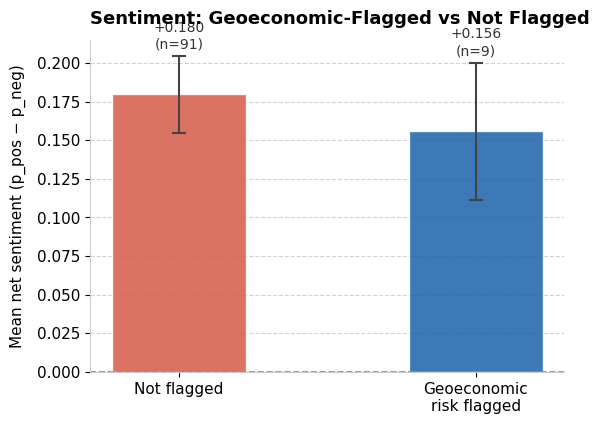

Saved figures/18_finbert_georisk_vs_not.png


In [8]:
# ── Fig 5: Sentiment — geoeconomic-flagged vs non-flagged ──────────────────

geo_sent = (
    df.dropna(subset=['any_georisk', 'net_sentiment'])
    .groupby('any_georisk')
    .agg(mean_net=('net_sentiment', 'mean'),
         std=('net_sentiment', 'std'),
         n=('net_sentiment', 'count'))
    .reset_index()
)
geo_sent['label'] = geo_sent['any_georisk'].map(
    {True: 'Geoeconomic\nrisk flagged', False: 'Not flagged'})
geo_sent['se'] = geo_sent['std'] / np.sqrt(geo_sent['n'])

fig, ax = plt.subplots(figsize=(6, 4.5))
GEO_COLORS = ['#D6604D', '#2166AC']
bars = ax.bar(geo_sent['label'], geo_sent['mean_net'],
              color=GEO_COLORS, alpha=0.88, edgecolor='white',
              linewidth=1.0, width=0.45,
              yerr=geo_sent['se'] * 1.96, capsize=5,
              error_kw={'elinewidth': 1.5, 'ecolor': '#444444', 'capthick': 1.5})

for bar, (_, row) in zip(bars, geo_sent.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            row['mean_net'] + row['se'] * 1.96 + 0.003,
            f"{row['mean_net']:+.3f}\n(n={row['n']:,})",
            ha='center', va='bottom', fontsize=10, color='#333333',
            linespacing=1.3)

ax.axhline(0, color='#888888', linewidth=1.2, linestyle='--')
ax.set_ylabel('Mean net sentiment (p_pos − p_neg)', fontsize=11, labelpad=8)
ax.set_title('Sentiment: Geoeconomic-Flagged vs Not Flagged',
             fontsize=13, fontweight='bold', pad=12, loc='left')
ax.yaxis.grid(True, linestyle='--', alpha=0.35, color='grey', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
plt.tight_layout(pad=1.5)
plt.savefig('figures/18_finbert_georisk_vs_not.png', dpi=160,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved figures/18_finbert_georisk_vs_not.png')

In [9]:
# Export merged results
out_cols = [
    'url', 'company_name', 'ticker', 'reporting_period', 'event_type',
    'dominant_label',
    'full_text__p_positive', 'full_text__p_negative', 'full_text__p_neutral',
    'full_text__sentiment', 'net_sentiment',
    'exec_net', 'analyst_net',
    'trade_risk', 'sanctions_risk', 'embargo_risk',
    'geopolitical_risk', 'any_georisk',
]
out_cols = [c for c in out_cols if c in df.columns]
df[out_cols].to_csv('data/finbert_results.csv', index=False)
print(f'Saved data/finbert_results.csv  ({len(df):,} rows)')

Saved data/finbert_results.csv  (100 rows)


## Summary

| File | Description |
|---|---|
| `data/finbert_sentiment.csv` | Raw FinBERT scores per document (all three text fields) |
| `data/finbert_results.csv` | Merged: scores + LDA topics + geoeconomic flags |
| `figures/14_finbert_sentiment_dist.png` | Overall sentiment distribution |
| `figures/15_finbert_by_topic.png` | Net sentiment by LDA topic |
| `figures/16_finbert_by_period.png` | Net sentiment by reporting quarter |
| `figures/17_finbert_exec_vs_analyst.png` | Executive vs analyst sentiment |
| `figures/18_finbert_georisk_vs_not.png` | Geoeconomic-flagged vs non-flagged sentiment |